In [8]:
import pandas as pd

# Load the files using the correct path you just confirmed
gen_df = pd.read_csv("/content/Plant_1_Generation_Data.csv")
weather_df = pd.read_csv("/content/Plant_1_Weather_Sensor_Data.csv")

# --- From here, the rest of your Week 1 code is the same ---

# Convert the text 'DATE_TIME' columns into real datetime objects
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Merge them into one master table on the 'DATE_TIME' column
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='inner')

# Check for any missing data
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Simple way to clean: drop any rows that have missing data
df = df.dropna()

print("\n--- Merged Data Ready ---")
print(df.head())

--- Missing Values Check ---
DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

--- Merged Data Ready ---
   DATE_TIME  PLANT_ID_x     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15     4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15     4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15     4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15     4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15     4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  AMBIENT_TEMPERATURE  \
0    6259559.0     4135001  HmiyD2TTLFNqkNe            25.184316   
1    6183645.0     4135001

/tmp/ipython-input-3858280783.py:10: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])


In [9]:
# --- 1. Filter for Daylight Hours ---
# We only want to predict power when the sun is out.
# This simplifies the problem and makes our model more accurate.
df_daylight = df[df['IRRADIATION'] > 0.01].copy()

# --- 2. Create Time-Based Features ---
# The model needs numbers, not datetimes.
df_daylight['hour'] = df_daylight['DATE_TIME'].dt.hour
df_daylight['month'] = df_daylight['DATE_TIME'].dt.month

print("\n--- Data with New Features ---")
print(df_daylight.head())


--- Data with New Features ---
              DATE_TIME  PLANT_ID_x     SOURCE_KEY_x    DC_POWER   AC_POWER  \
531 2020-05-15 06:15:00     4135001  1BY6WEcLGh8j5v7  278.000000  26.862500   
532 2020-05-15 06:15:00     4135001  1IF53ai7Xc0U56Y  310.571429  30.014286   
533 2020-05-15 06:15:00     4135001  3PZuoBAID5Wc2HD  318.625000  30.775000   
534 2020-05-15 06:15:00     4135001  7JYdWkrLSPkdwr4  316.250000  30.562500   
535 2020-05-15 06:15:00     4135001  McdE0feGgRqW7Ca  311.428571  30.100000   

     DAILY_YIELD  TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  \
531     2.625000  6259561.625     4135001  HmiyD2TTLFNqkNe   
532     3.000000  6183648.000     4135001  HmiyD2TTLFNqkNe   
533     3.500000  6987762.500     4135001  HmiyD2TTLFNqkNe   
534     3.500000  7602963.500     4135001  HmiyD2TTLFNqkNe   
535     3.142857  7158967.143     4135001  HmiyD2TTLFNqkNe   

     AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  hour  month  
531            24.011635           22.353459   

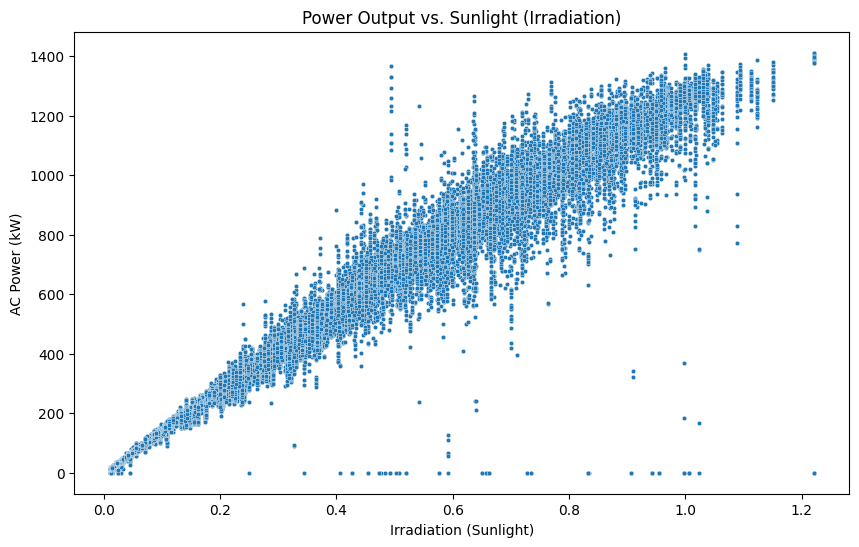

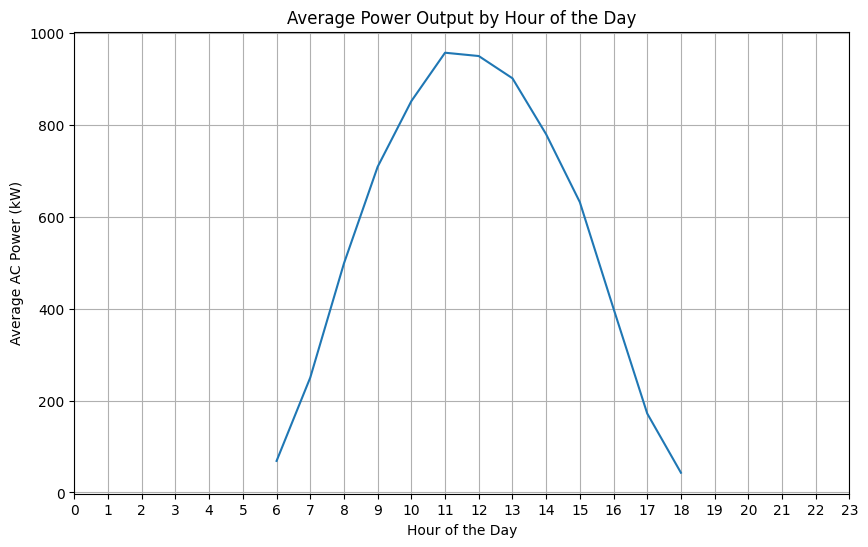

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Graph 1: The "Money Plot" (Sunlight vs. Power) ---
# This shows the most important relationship in your data.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IRRADIATION', y='AC_POWER', data=df_daylight, s=10)
plt.title('Power Output vs. Sunlight (Irradiation)')
plt.xlabel('Irradiation (Sunlight)')
plt.ylabel('AC Power (kW)')
plt.show()


# --- Graph 2: The Daily Pattern (Hour vs. Power) ---
# This shows the daily cycle of power generation.
plt.figure(figsize=(10, 6))
sns.lineplot(x='hour', y='AC_POWER', data=df_daylight, errorbar=None)
plt.title('Average Power Output by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average AC Power (kW)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [11]:
# --- Step 1: Define Your Features (X) and Target (y) ---

features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'hour', 'month']
X = df_daylight[features]

y = df_daylight['AC_POWER']

print("--- X (Features) Head ---")
print(X.head())

print("\n--- y (Target) Head ---")
print(y.head())

--- X (Features) Head ---
     IRRADIATION  AMBIENT_TEMPERATURE  hour  month
531     0.022282            24.011635     6      5
532     0.022282            24.011635     6      5
533     0.022282            24.011635     6      5
534     0.022282            24.011635     6      5
535     0.022282            24.011635     6      5

--- y (Target) Head ---
531    26.862500
532    30.014286
533    30.775000
534    30.562500
535    30.100000
Name: AC_POWER, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (28750, 4)
Testing data shape: (7188, 4)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# --- Model 1: Linear Regression ---
print("Training Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Model 2: Random Forest ---
print("Training Random Forest model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("\n--- Training Complete ---")

# --- Get Predictions ---
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# --- Score the Models ---
lr_score = r2_score(y_test, lr_preds)
rf_score = r2_score(y_test, rf_preds)

print(f"\n--- Model Results ---")
print(f"Linear Regression R-squared: {lr_score:.4f}")
print(f"Random Forest R-squared: {rf_score:.4f}")

Training Linear Regression model...
Training Random Forest model...

--- Training Complete ---

--- Model Results ---
Linear Regression R-squared: 0.9495
Random Forest R-squared: 0.9637


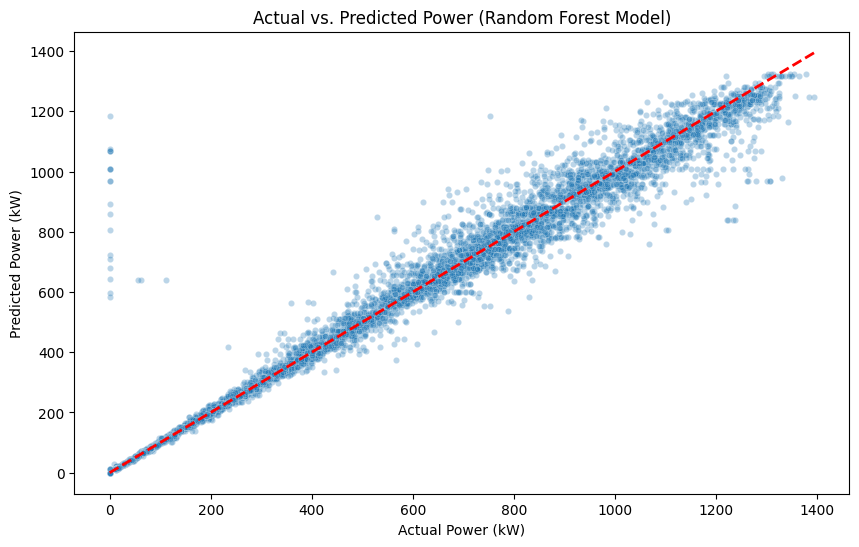

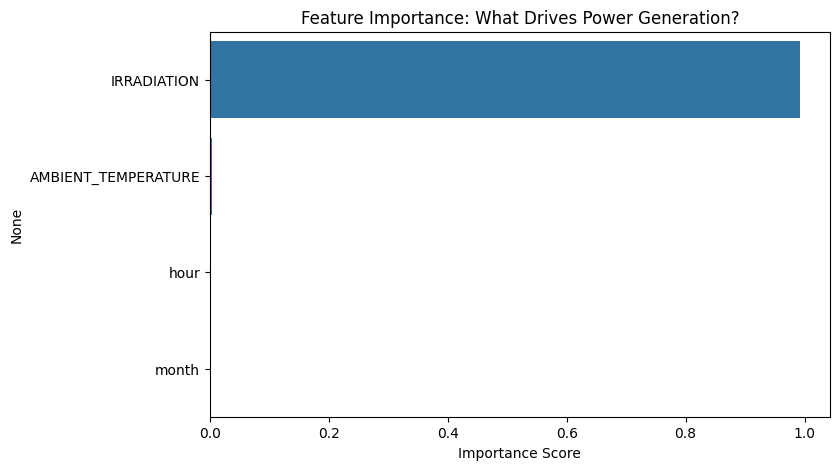

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Graph 1: Actual vs. Predicted (The Proof) ---
plt.figure(figsize=(10, 6))
# Plot the actual values (y_test) vs. the predicted values (rf_preds)
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.3, s=20)

# Plot the "perfect" prediction line (Red Dashed Line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('Actual vs. Predicted Power (Random Forest Model)')
plt.show()

# --- Graph 2: Feature Importance (The Logic) ---
# Ask the Random Forest which features were most important
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance: What Drives Power Generation?')
plt.xlabel('Importance Score')
plt.show()